<a href="https://colab.research.google.com/github/anthony-yt/wildfire-cellular-automata/blob/aut%C3%B3mata-celular_yosue_1/notebooks/prueba_grid_sintetico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prueba del Grid
Probamos el grid con datos sintéticos, todavía sin viento, para ver que el fuego se expande en unos pasos.

In [68]:
import os

if os.path.exists('src'):
    pass
elif os.path.exists('../src'):
    %cd ..
else:
    if not os.path.exists('wildfire-cellular-automata'):
        !git clone https://github.com/anthony-yt/wildfire-cellular-automata.git
    %cd wildfire-cellular-automata

In [69]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from src.model.grid import Grid, SANA, NO_COMBUSTIBLE

In [70]:
AGUA = 4
ROCA = 5

grid = Grid(tamano=100, prob_ignicion_base=0.5, pasos_para_quemarse=2, semilla=42)

np.random.seed(101)
filas = np.arange(grid.tamano)

onda_base = 12 * np.sin(filas / 18.0)
onda_media = 5 * np.cos(filas / 7.0 + 1.2)
onda_fina = 2.5 * np.sin(filas / 3.2)
ruido_pasos = np.random.normal(loc=0, scale=0.4, size=grid.tamano)
ruido_acumulado = np.cumsum(ruido_pasos)

col_centro_rio = 65 + onda_base + onda_media + onda_fina + ruido_acumulado

ancho_rio = 3
for f in range(grid.tamano):
    c_cen = int(round(col_centro_rio[f]))
    c_ini = max(0, c_cen - ancho_rio // 2)
    c_fin = min(grid.tamano, c_cen + (ancho_rio // 2) + 1)
    grid.estado[f, c_ini:c_fin] = AGUA

centro_rocas = (42, 32)
radio_rocas = 9

for r in range(grid.tamano):
    for c in range(grid.tamano):
        distancia = np.hypot(r - centro_rocas[0], (c - centro_rocas[1]) * 1.2)
        umbral_rugoso = radio_rocas + np.random.uniform(-1.5, 1.5)
        if distancia < umbral_rugoso:
            grid.estado[r, c] = ROCA

centro = grid.tamano // 2
grid.encender_celda(centro, centro)

grid.contar_estados()

{'Sana': 9489, 'Quemandose': 1, 'Quemada': 0, 'No_combustible': 0}

In [71]:
colores = ListedColormap(['forestgreen', 'crimson', 'black', 'gray', 'deepskyblue', 'dimgray'])

def graficar_grid(grid, titulo=''):
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.estado, cmap=colores, vmin=0, vmax=5)
    plt.title(titulo, fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()

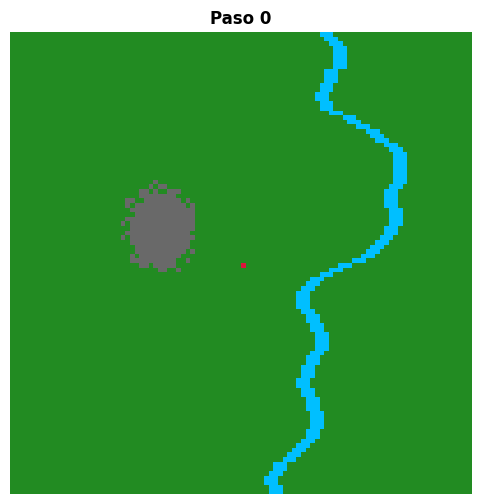

Paso 1: {'Sana': 9488, 'Quemandose': 2, 'Quemada': 0, 'No_combustible': 0}


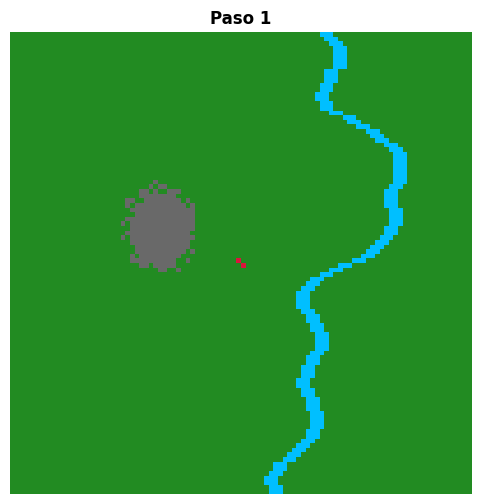

Paso 2: {'Sana': 9486, 'Quemandose': 3, 'Quemada': 1, 'No_combustible': 0}


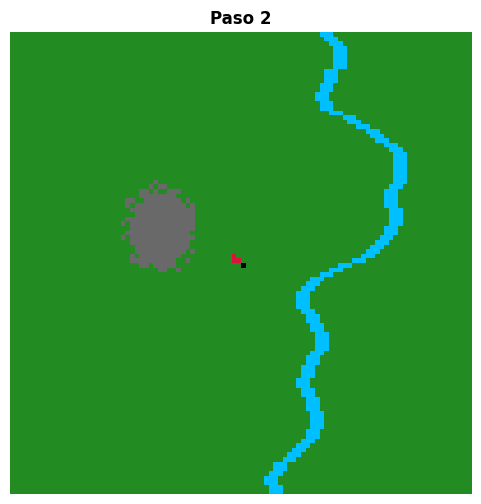

Paso 3: {'Sana': 9483, 'Quemandose': 5, 'Quemada': 2, 'No_combustible': 0}


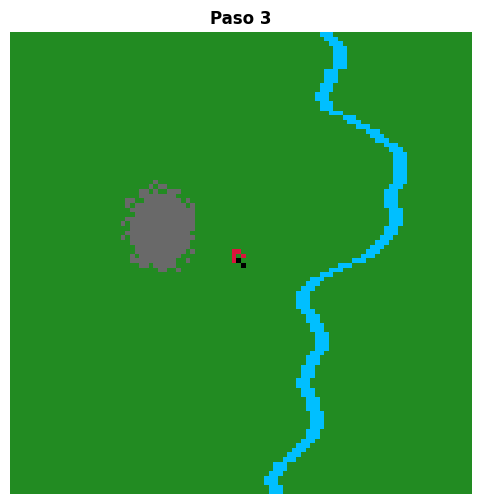

Paso 4: {'Sana': 9480, 'Quemandose': 6, 'Quemada': 4, 'No_combustible': 0}


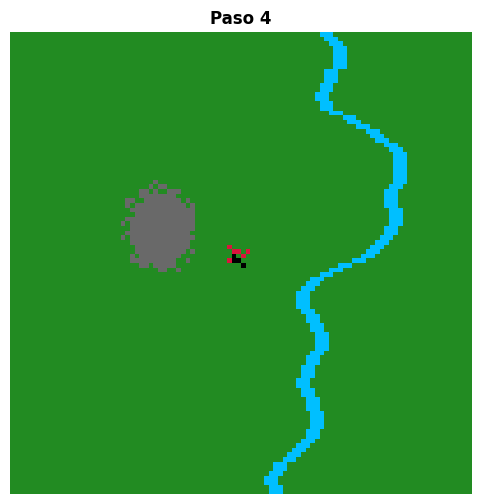

Paso 5: {'Sana': 9478, 'Quemandose': 5, 'Quemada': 7, 'No_combustible': 0}


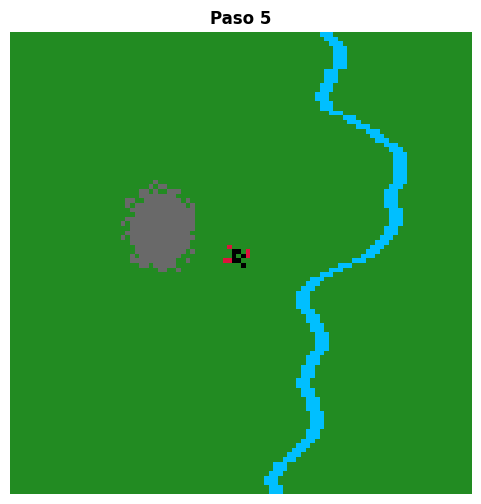

Paso 6: {'Sana': 9470, 'Quemandose': 10, 'Quemada': 10, 'No_combustible': 0}


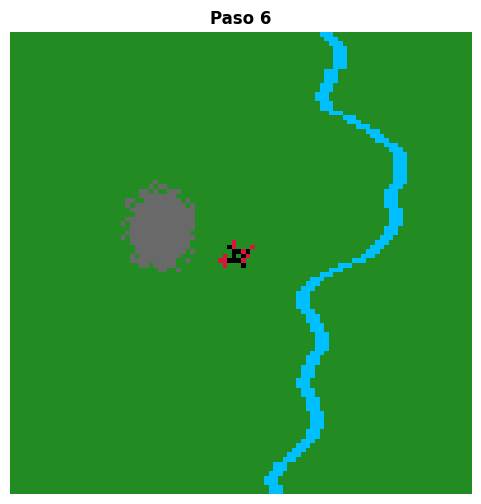

Paso 7: {'Sana': 9457, 'Quemandose': 21, 'Quemada': 12, 'No_combustible': 0}


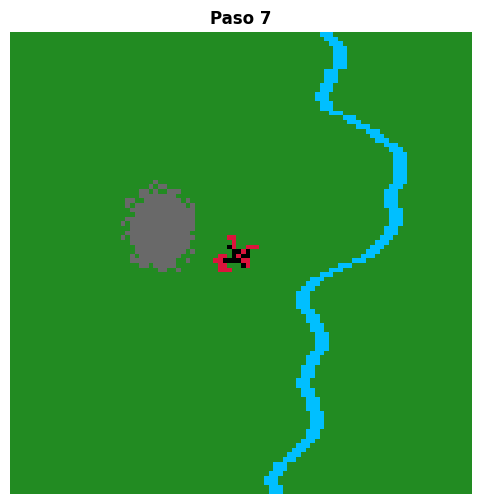

Paso 8: {'Sana': 9446, 'Quemandose': 24, 'Quemada': 20, 'No_combustible': 0}


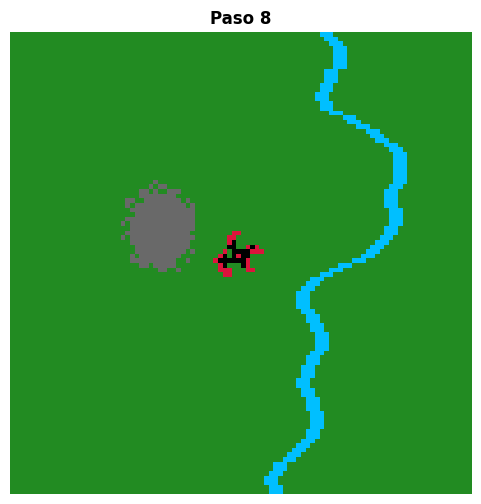

Paso 9: {'Sana': 9437, 'Quemandose': 20, 'Quemada': 33, 'No_combustible': 0}


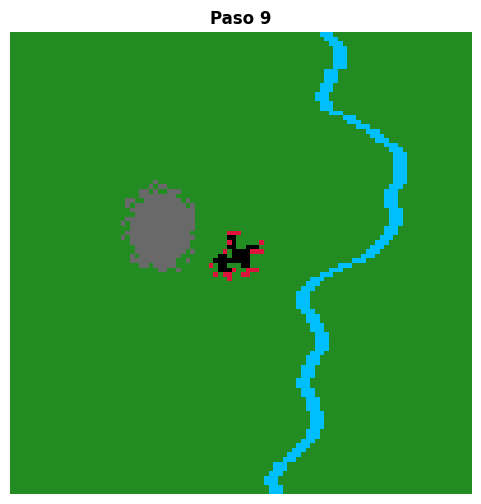

Paso 10: {'Sana': 9423, 'Quemandose': 23, 'Quemada': 44, 'No_combustible': 0}


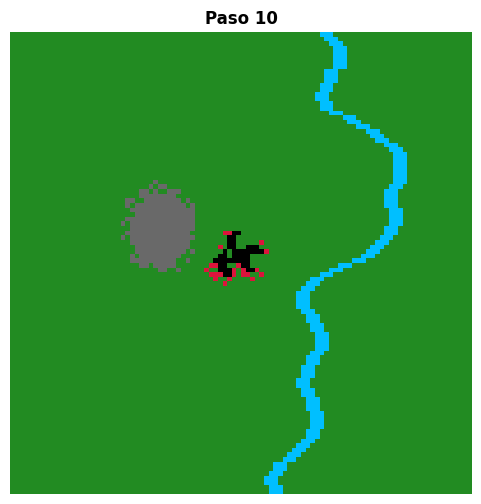

Paso 11: {'Sana': 9412, 'Quemandose': 25, 'Quemada': 53, 'No_combustible': 0}


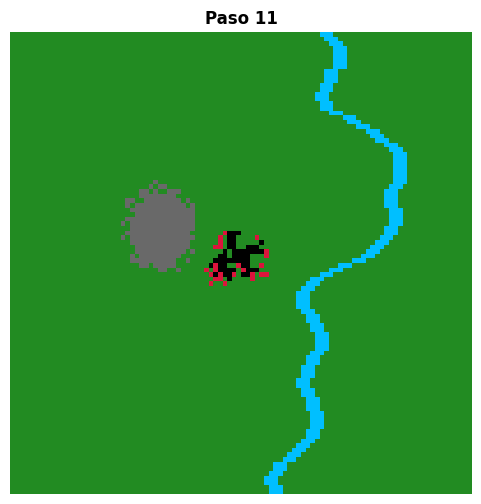

Paso 12: {'Sana': 9402, 'Quemandose': 21, 'Quemada': 67, 'No_combustible': 0}


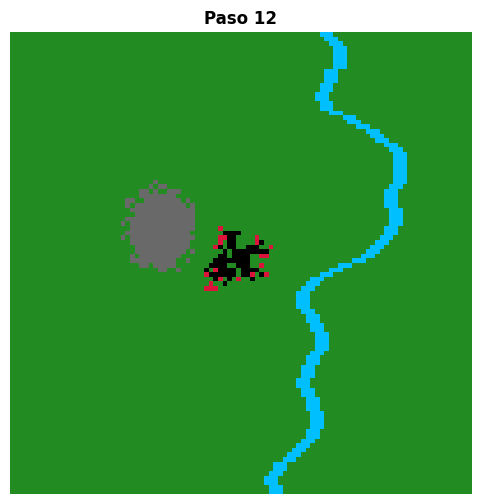

Paso 13: {'Sana': 9382, 'Quemandose': 30, 'Quemada': 78, 'No_combustible': 0}


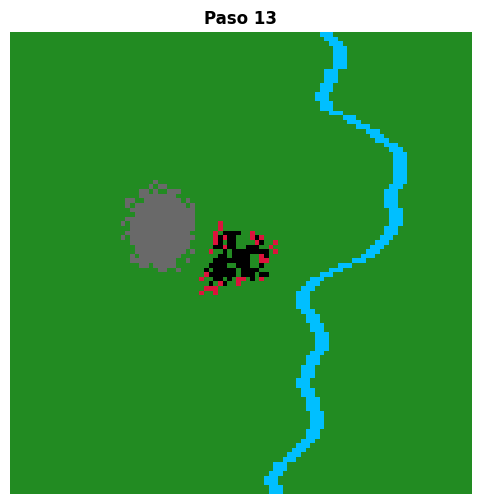

Paso 14: {'Sana': 9369, 'Quemandose': 33, 'Quemada': 88, 'No_combustible': 0}


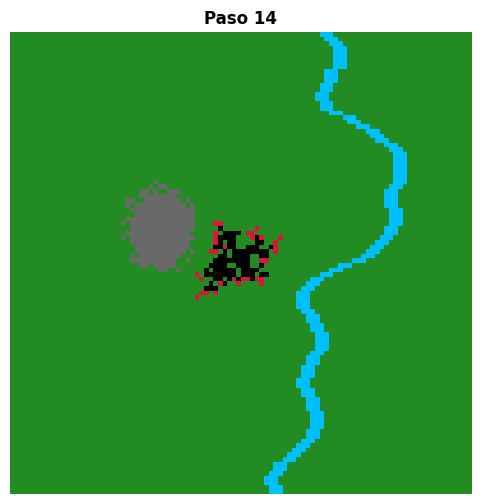

Paso 15: {'Sana': 9345, 'Quemandose': 37, 'Quemada': 108, 'No_combustible': 0}


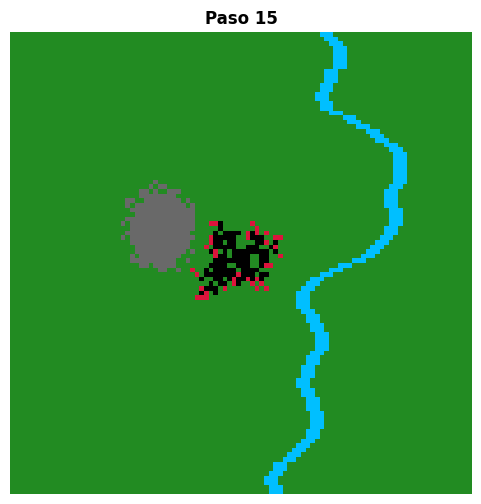

Paso 16: {'Sana': 9316, 'Quemandose': 53, 'Quemada': 121, 'No_combustible': 0}


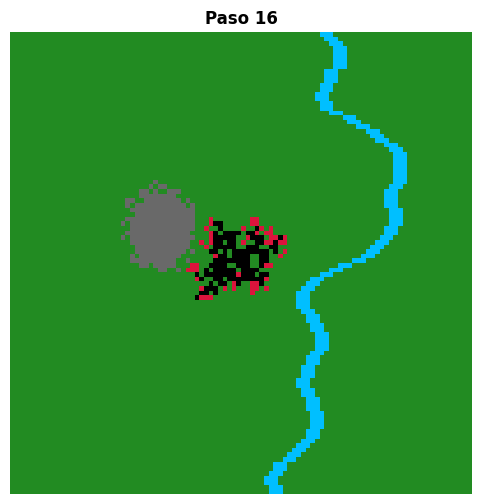

Paso 17: {'Sana': 9298, 'Quemandose': 47, 'Quemada': 145, 'No_combustible': 0}


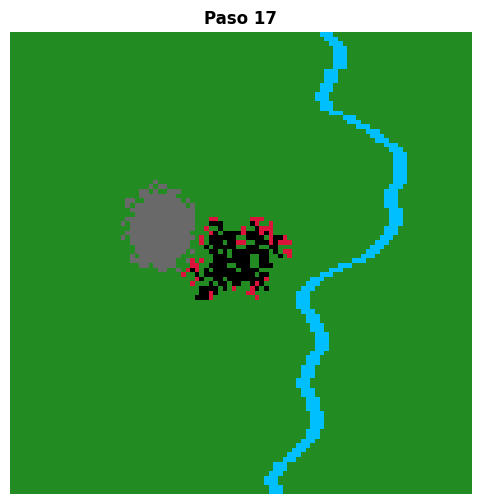

Paso 18: {'Sana': 9274, 'Quemandose': 42, 'Quemada': 174, 'No_combustible': 0}


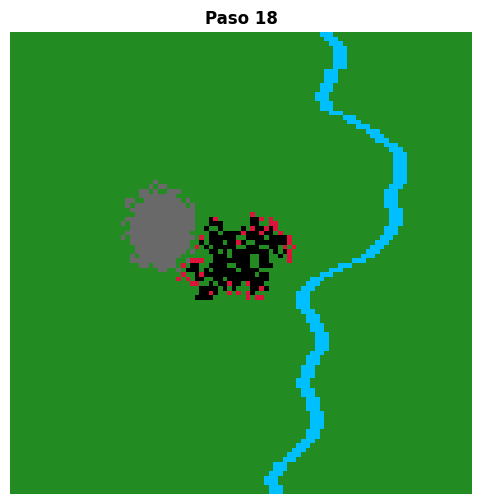

Paso 19: {'Sana': 9252, 'Quemandose': 46, 'Quemada': 192, 'No_combustible': 0}


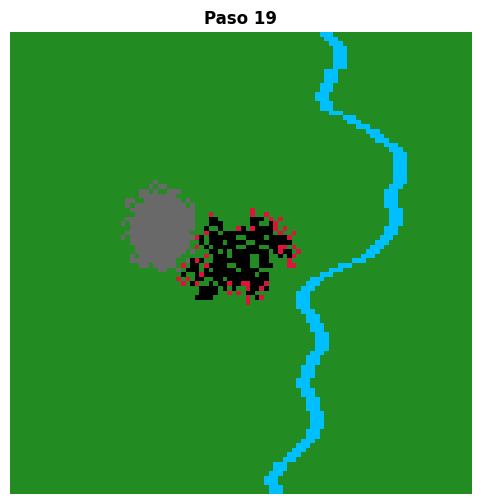

Paso 20: {'Sana': 9218, 'Quemandose': 56, 'Quemada': 216, 'No_combustible': 0}


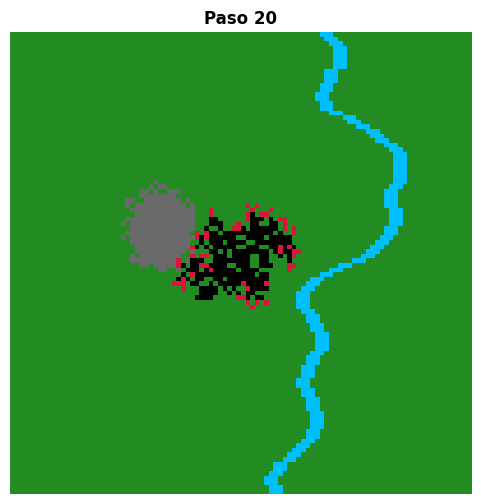

Paso 21: {'Sana': 9196, 'Quemandose': 56, 'Quemada': 238, 'No_combustible': 0}


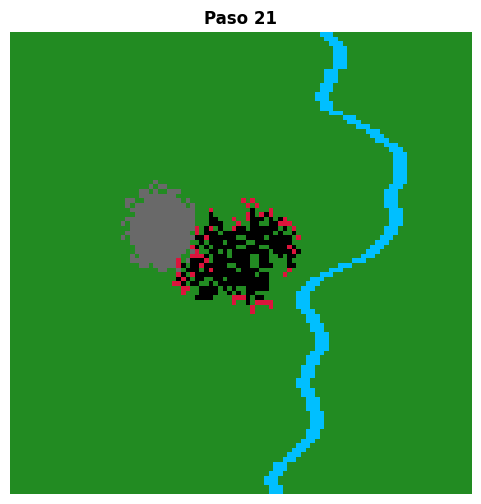

Paso 22: {'Sana': 9168, 'Quemandose': 50, 'Quemada': 272, 'No_combustible': 0}


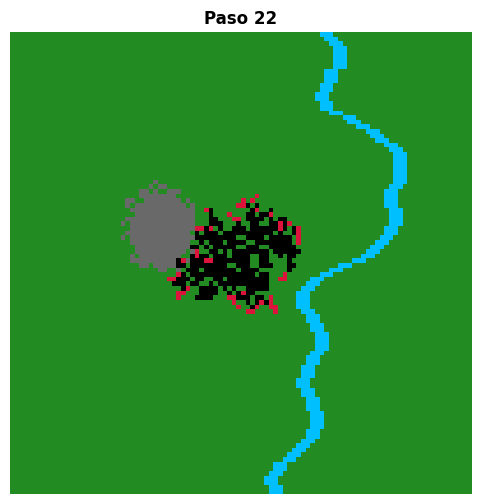

Paso 23: {'Sana': 9141, 'Quemandose': 55, 'Quemada': 294, 'No_combustible': 0}


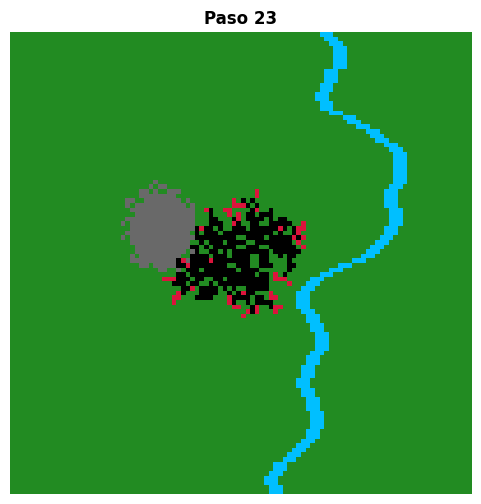

Paso 24: {'Sana': 9110, 'Quemandose': 58, 'Quemada': 322, 'No_combustible': 0}


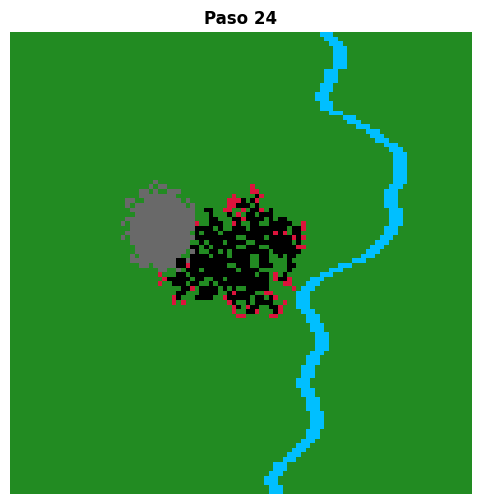

Paso 25: {'Sana': 9079, 'Quemandose': 62, 'Quemada': 349, 'No_combustible': 0}


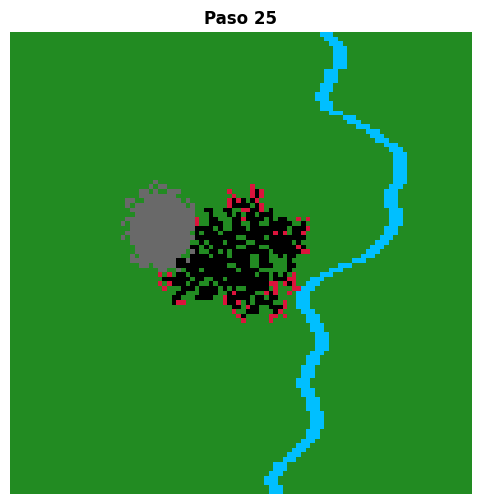

Paso 26: {'Sana': 9042, 'Quemandose': 68, 'Quemada': 380, 'No_combustible': 0}


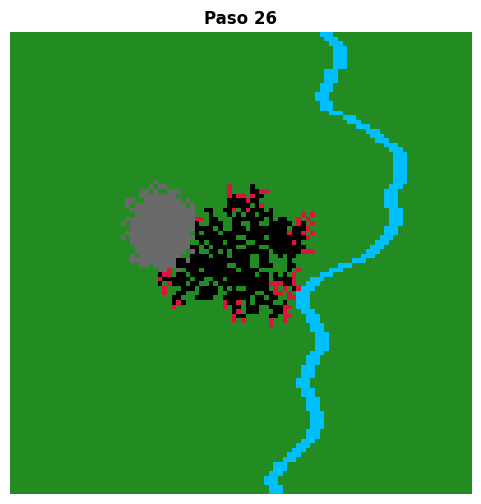

Paso 27: {'Sana': 9017, 'Quemandose': 62, 'Quemada': 411, 'No_combustible': 0}


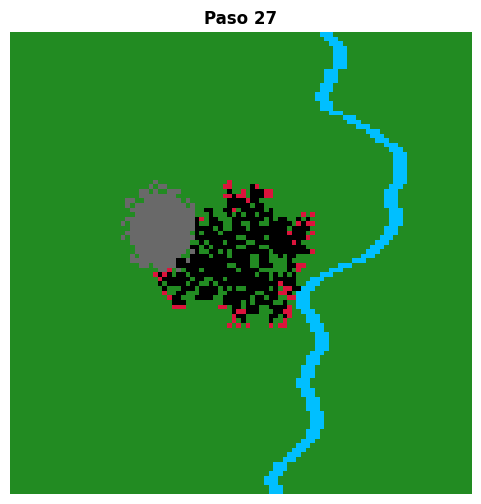

Paso 28: {'Sana': 8981, 'Quemandose': 61, 'Quemada': 448, 'No_combustible': 0}


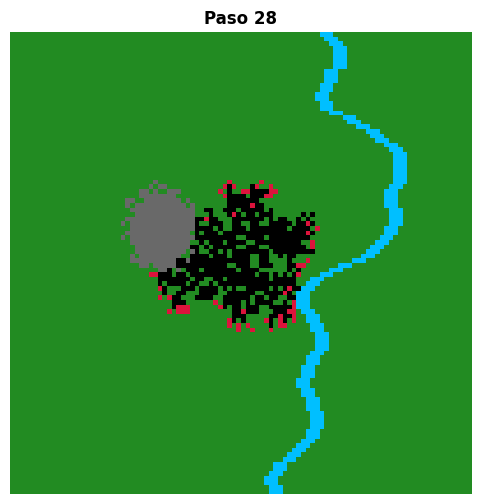

Paso 29: {'Sana': 8949, 'Quemandose': 68, 'Quemada': 473, 'No_combustible': 0}


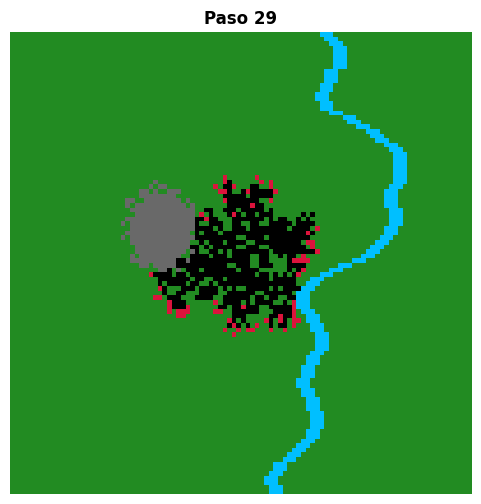

Paso 30: {'Sana': 8906, 'Quemandose': 75, 'Quemada': 509, 'No_combustible': 0}


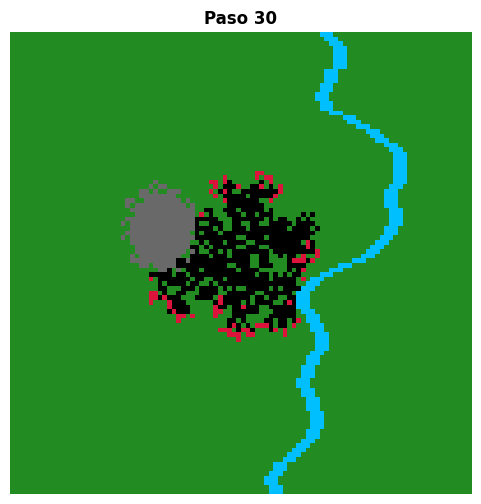

In [72]:
graficar_grid(grid, 'Paso 0')

for paso in range(1, 31):
    grid.paso_tiempo()
    print(f'Paso {paso}:', grid.contar_estados())
    graficar_grid(grid, f'Paso {paso}')